# Access the analysis ready satellite cloud properties data

This notebook provides an example of how to open the satellite-cloud-properties Zarr store using xarray.
You will need to insert your CDS API key where indicated in the following code cell (available on [your profile page](https://cds.climate.copernicus.eu/profile)).
For more information on using the Data Store Analysis Ready Datasets, please see the [user documentation pages](https://cds.climate.copernicus.eu/datasets/how-to-use-the-dss-arco-dataset).

In [1]:
import os
cdsapi_key = "<INSERT-CDS-API-KEY-HERE>"

# The following attempts to find the CDSAPI key in your environment.
if cdsapi_key == "<INSERT-CDS-API-KEY-HERE>":
    cdsapi_key = None
if cdsapi_key is None:
    cdsapi_key = os.getenv("CDSAPI_KEY")
if cdsapi_key is None and os.path.exists(os.path.expanduser("~/.cdsapirc")):
    with open(os.path.expanduser("~/.cdsapirc"), "r") as f:
        for line in f:
            if line.startswith("key:"):
                cdsapi_key = line.split(":")[1].strip()
                break
if cdsapi_key is None:
    raise ValueError("CDSAPI key not found. Please set the CDSAPI_KEY environment variable or create a ~/.cdsapirc file.")


## Plug and play access

The code below provides a simple plug and play example of how to use the Zarr Store for light-weight access.

In [2]:
import xarray as xr

# Geo-chunked ICDR SLSTR Sentinel-3A data
geochunked_icdr_slstr_s3a_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-051/arco/satellite_cloud_properties/icdr-slstr-s3a/geoChunked.zarr"

# Time-chunked ICDR SLSTR Sentinel-3A data
timechunked_icdr_slstr_s3a_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-051/arco/satellite_cloud_properties/icdr-slstr-s3a/timeChunked.zarr"

# Geo-chunked ICDR SLSTR Sentinel-3A & 3B (equal angle) data
geochunked_icdr_slstr_s3ab_equal_angle_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-051/arco/satellite_cloud_properties/icdr-slstr-s3ab-equal-angle/geoChunked.zarr"

# Time-chunked ICDR SLSTR Sentinel-3A & 3B (equal angle) data
timechunked_icdr_slstr_s3ab_equal_angle_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-051/arco/satellite_cloud_properties/icdr-slstr-s3ab-equal-angle/timeChunked.zarr"

# Geo-chunked ICDR SLSTR Sentinel-3A & 3B (equal area) data
geochunked_icdr_slstr_s3ab_equal_area_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-051/arco/satellite_cloud_properties/icdr-slstr-s3ab-equal-area/geoChunked.zarr"

# Time-chunked ICDR SLSTR Sentinel-3A & 3B (equal area) data
timechunked_icdr_slstr_s3ab_equal_area_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-051/arco/satellite_cloud_properties/icdr-slstr-s3ab-equal-area/timeChunked.zarr"

# Geo-chunked ICDR SLSTR Sentinel-3B data
geochunked_icdr_slstr_s3b_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-051/arco/satellite_cloud_properties/icdr-slstr-s3b/geoChunked.zarr"

# Time-chunked ICDR SLSTR Sentinel-3B data
timechunked_icdr_slstr_s3b_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-051/arco/satellite_cloud_properties/icdr-slstr-s3b/timeChunked.zarr"

# Geo-chunked TCDR ATSR2 on ERS2 data
geochunked_tcdr_atsr2_ers2_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-051/arco/satellite_cloud_properties/tcdr-atsr2-ers2/geoChunked.zarr"

# Time-chunked TCDR ATSR2 on ERS2 data
timechunked_tcdr_atsr2_ers2_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-051/arco/satellite_cloud_properties/tcdr-atsr2-ers2/timeChunked.zarr"

# Geo-chunked TCDR AATSR on ENVISAT data
geochunked_tcdr_aatsr_envisat_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-051/arco/satellite_cloud_properties/tcdr-aatsr-envisat/geoChunked.zarr"

# Time-chunked TCDR AATSR on ENVISAT data
timechunked_tcdr_aatsr_envisat_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-051/arco/satellite_cloud_properties/tcdr-aatsr-envisat/timeChunked.zarr"


# Open the zarr store with xarray, users must insert their API key where indicated.
ds = xr.open_zarr(
    timechunked_icdr_slstr_s3a_url,
    consolidated=True,
     storage_options = {
        "headers": {"Authorization": f"Bearer {cdsapi_key}"}
    }
)
 
# Inspect the variables
ds

<xarray.Dataset> Size: 5TB
Dimensions:             (time: 1963, latitude: 1800, longitude: 3600)
Coordinates:
  * time                (time) datetime64[ns] 16kB 2017-01-01 ... 2022-06-30
  * latitude            (latitude) float32 7kB -89.95 -89.85 ... 89.85 89.95
  * longitude           (longitude) float32 14kB -179.9 -179.9 ... 179.9 179.9
Data variables: (12/52)
    pixel_time_night    (time, latitude, longitude) float64 102GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    cer_day             (time, latitude, longitude) float64 102GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    cer_day_cor         (time, latitude, longitude) float64 102GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    cer_day_std         (time, latitude, longitude) float64 102GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    cer_day_unc         (time, latitude, longitude) float64 102GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    cfc_day             (time, latitude, longitude) float64 102GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    ...                  ...
    pixel_count_day     (time, latitude, longitude) float64 102GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    pixel_count_night   (time, latitude, longitude) float64 102GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    pixel_time_day      (time, latitude, longitude) float64 102GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    cfc_day_std         (time, latitude, longitude) float64 102GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    cfc_night_std       (time, latitude, longitude) float64 102GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    cth_day             (time, latitude, longitude) float64 102GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>

Plot a map of daytime cloud fraction from the ICDR SLSTR Sentinel-3A dataset using earthkit-plots.

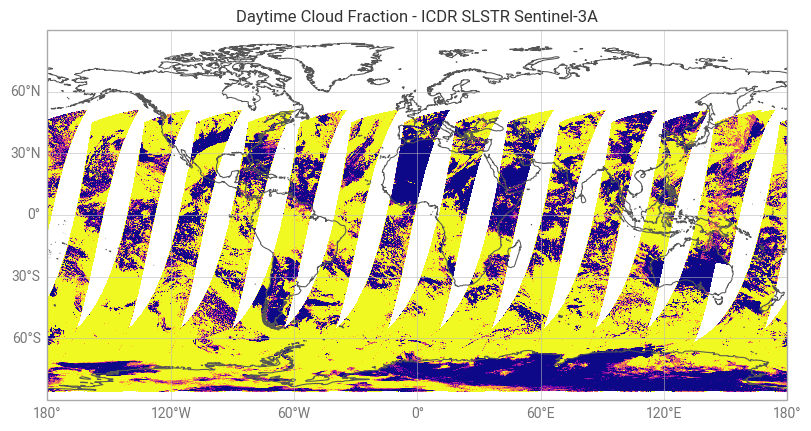

In [3]:
from earthkit import plots as ekp

# Select a single time step to plot
plot_data = ds["cfc_day"].sel(time="2020-01-01", method="nearest")

chart = ekp.Map()

chart.grid_cells(plot_data)

chart.coastlines()
chart.gridlines()

chart.title("Daytime Cloud Fraction - ICDR SLSTR Sentinel-3A")

chart.show()

## Advanced usage

If your workflow requires access to larger amounts of data, it is recommended that you include a retry mechanism.
This is not provided in the current default zarr engine for xarray, instead we can define a custom "`store`" which is
used when connecting to the remote zarr data.

In [4]:
!pip install -q obstore
import xarray as xr
from obstore.store import HTTPStore
from zarr.storage import ObjectStore

# Geo-chunked ICDR SLSTR Sentinel-3A data
geochunked_icdr_slstr_s3a_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-051/arco/satellite_cloud_properties/icdr-slstr-s3a/geoChunked.zarr"

# Time-chunked ICDR SLSTR Sentinel-3A data
timechunked_icdr_slstr_s3a_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-051/arco/satellite_cloud_properties/icdr-slstr-s3a/timeChunked.zarr"

# Geo-chunked ICDR SLSTR Sentinel-3A & 3B (equal angle) data
geochunked_icdr_slstr_s3ab_equal_angle_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-051/arco/satellite_cloud_properties/icdr-slstr-s3ab-equal-angle/geoChunked.zarr"

# Time-chunked ICDR SLSTR Sentinel-3A & 3B (equal angle) data
timechunked_icdr_slstr_s3ab_equal_angle_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-051/arco/satellite_cloud_properties/icdr-slstr-s3ab-equal-angle/timeChunked.zarr"

# Geo-chunked ICDR SLSTR Sentinel-3A & 3B (equal area) data
geochunked_icdr_slstr_s3ab_equal_area_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-051/arco/satellite_cloud_properties/icdr-slstr-s3ab-equal-area/geoChunked.zarr"

# Time-chunked ICDR SLSTR Sentinel-3A & 3B (equal area) data
timechunked_icdr_slstr_s3ab_equal_area_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-051/arco/satellite_cloud_properties/icdr-slstr-s3ab-equal-area/timeChunked.zarr"

# Geo-chunked ICDR SLSTR Sentinel-3B data
geochunked_icdr_slstr_s3b_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-051/arco/satellite_cloud_properties/icdr-slstr-s3b/geoChunked.zarr"

# Time-chunked ICDR SLSTR Sentinel-3B data
timechunked_icdr_slstr_s3b_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-051/arco/satellite_cloud_properties/icdr-slstr-s3b/timeChunked.zarr"

# Geo-chunked TCDR ATSR2 on ERS2 data
geochunked_tcdr_atsr2_ers2_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-051/arco/satellite_cloud_properties/tcdr-atsr2-ers2/geoChunked.zarr"

# Time-chunked TCDR ATSR2 on ERS2 data
timechunked_tcdr_atsr2_ers2_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-051/arco/satellite_cloud_properties/tcdr-atsr2-ers2/timeChunked.zarr"

# Geo-chunked TCDR AATSR on ENVISAT data
geochunked_tcdr_aatsr_envisat_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-051/arco/satellite_cloud_properties/tcdr-aatsr-envisat/geoChunked.zarr"

# Time-chunked TCDR AATSR on ENVISAT data
timechunked_tcdr_aatsr_envisat_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-051/arco/satellite_cloud_properties/tcdr-aatsr-envisat/timeChunked.zarr"


# Use obstore's HTTPStore to create a store with retry configuration,
# and then wrap it in a zarr ObjectStore to read with xarray.
# See https://github.com/developmentseed/obstore/blob/main/obstore/python/obstore/_store/_retry.pyi
# for more details on the retry configuration options.
http_store = HTTPStore(
    geochunked_icdr_slstr_s3a_url,
    client_options={
        "default_headers": {"Authorization": f"Bearer {cdsapi_key}"},
    },
)
store = ObjectStore(http_store, read_only=True)
ds = xr.open_zarr(store)
ds

<xarray.Dataset> Size: 5TB
Dimensions:             (time: 1963, latitude: 1800, longitude: 3600)
Coordinates:
  * time                (time) datetime64[ns] 16kB 2017-01-01 ... 2022-06-30
  * latitude            (latitude) float32 7kB -89.95 -89.85 ... 89.85 89.95
  * longitude           (longitude) float32 14kB -179.9 -179.9 ... 179.9 179.9
Data variables: (12/52)
    pixel_time_night    (time, latitude, longitude) float64 102GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    cer_day             (time, latitude, longitude) float64 102GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    cer_day_cor         (time, latitude, longitude) float64 102GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    cer_day_std         (time, latitude, longitude) float64 102GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    cer_day_unc         (time, latitude, longitude) float64 102GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    cfc_day             (time, latitude, longitude) float64 102GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    ...                  ...
    pixel_count_day     (time, latitude, longitude) float64 102GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    pixel_count_night   (time, latitude, longitude) float64 102GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    pixel_time_day      (time, latitude, longitude) float64 102GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    cfc_day_std         (time, latitude, longitude) float64 102GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    cfc_night_std       (time, latitude, longitude) float64 102GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    cth_day             (time, latitude, longitude) float64 102GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>

The result is the same as the previous example, this just provides a more robust connection, preventing your
workflow crashing due to temporary network issues.